## Beta distributions

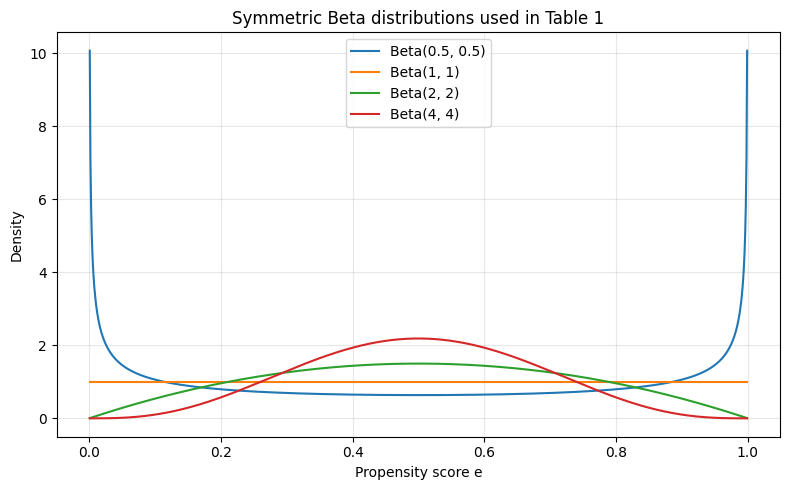

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

x = np.linspace(0.001, 0.999, 1000)

params = [0.5, 1, 2, 4]

plt.figure(figsize=(8, 5))
for a in params:
    y = beta.pdf(x, a, a)
    plt.plot(x, y, label=f"Beta({a}, {a})")

plt.xlabel("Propensity score e")
plt.ylabel("Density")
plt.title("Symmetric Beta distributions used in Table 1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As the Beta parameters increase symmetrically, more mass is concentrated around 0.5, which corresponds to better overlap. In contrast, Beta(0.5,0.5) places much more mass near 0 and 1, representing poor overlap and many extreme propensity scores.

## Why extreme propensity increases variance

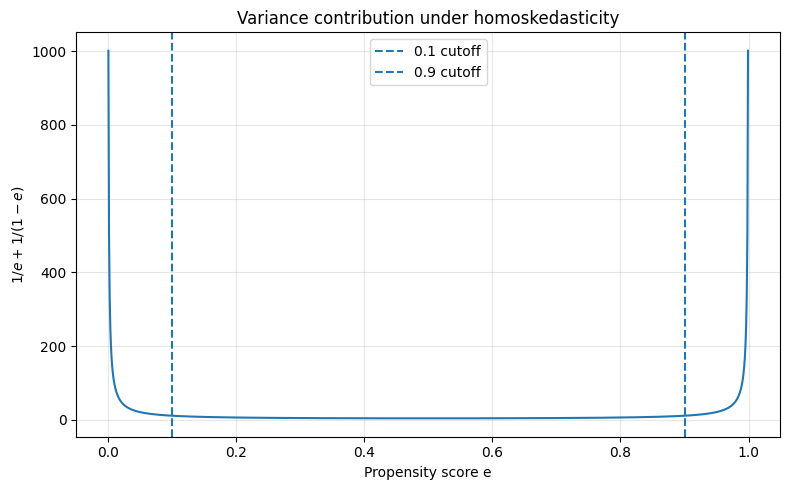

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.001, 0.999, 1000)
g = 1/x + 1/(1-x)

plt.figure(figsize=(8, 5))
plt.plot(x, g)
plt.axvline(0.1, linestyle="--", label="0.1 cutoff")
plt.axvline(0.9, linestyle="--", label="0.9 cutoff")
plt.xlabel("Propensity score e")
plt.ylabel(r"$1/e + 1/(1-e)$")
plt.title("Variance contribution under homoskedasticity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The variance contribution is smallest near e=0.5 and increases sharply as e approaches 0 or 1. This is why observations with extreme propensity scores can disproportionately increase the variance of the treatment effect estimator.

## Beta density + 0.1 cutoff shading

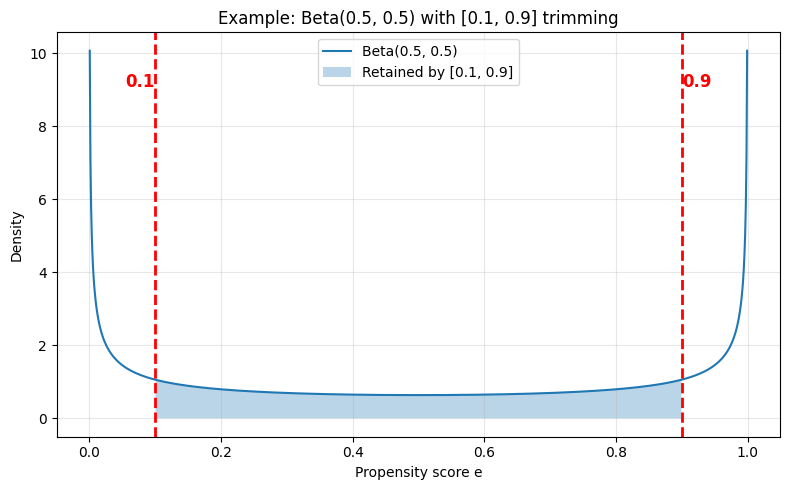

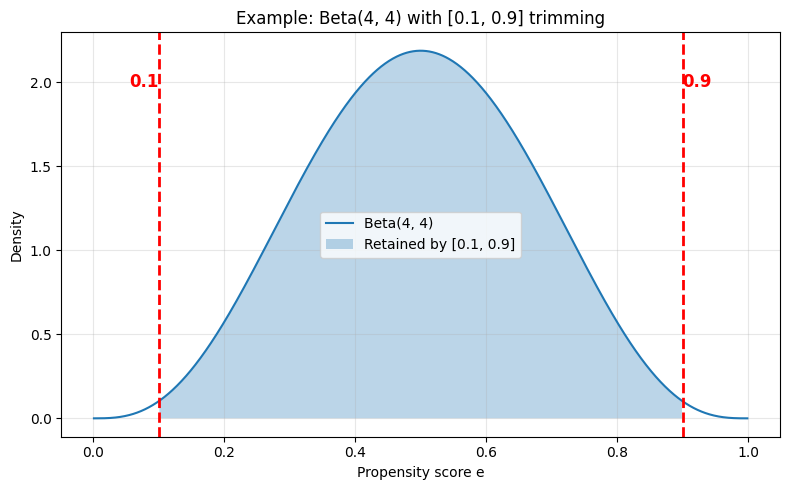

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def plot_beta_with_cutoff(a, b):
    x = np.linspace(0.001, 0.999, 1000)
    y = beta.pdf(x, a, b)

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label=f"Beta({a}, {b})")

    mask = (x >= 0.1) & (x <= 0.9)
    plt.fill_between(
        x[mask], y[mask],
        alpha=0.3,
        label="Retained by [0.1, 0.9]"
    )

    # cutoff lines
    plt.axvline(0.1, color="red", linestyle="--", linewidth=2)
    plt.axvline(0.9, color="red", linestyle="--", linewidth=2)

    # define max height for text placement
    ymax = y.max()

    plt.text(
        0.1, ymax * 0.9, "0.1",
        color="red",
        ha="right",
        fontsize=12,
        fontweight="bold"
    )

    plt.text(
        0.9, ymax * 0.9, "0.9",
        color="red",
        ha="left",
        fontsize=12,
        fontweight="bold"
    )

    plt.xlabel("Propensity score e")
    plt.ylabel("Density")
    plt.title(f"Example: Beta({a}, {b}) with [0.1, 0.9] trimming")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_beta_with_cutoff(0.5, 0.5)
plot_beta_with_cutoff(4, 4)

In the Beta(0.5, 0.5) case, much of the propensity-score density is concentrated near 0 and 1, where overlap is poor. Trimming at 0.1 and 0.9 removes these extreme regions and retains the central portion of the distribution.